# 📊 Customer Churn Analysis & Prediction

## 👨‍💻 By Himanshu Nangwal

### 🎯 Objective:
To analyze customer churn patterns and identify key factors that influence customer retention, and to build a basic model to predict churn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

## 1. Data Loading

The dataset contains customer information such as demographics, account details, subscribed services, and churn status. The main goal is to understand why customers leave and identify the factors that influence churn.

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Understanding

- The dataset includes features such as gender, tenure, monthly charges, total charges, contract type, and internet service.
- The target variable is **Churn**, which tells us whether a customer left the company or not.
- Understanding the structure of the data is important before cleaning and analysis.

In [4]:
df.info()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-nu

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3. Data Cleaning

- Converted the `TotalCharges` column into numeric format.
- Handled missing values using median replacement.
- Removed unnecessary columns such as `customerID`.
- Ensured the dataset is clean and ready for analysis.

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [10]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [11]:
df = df.drop("customerID", axis=1)

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploratory Data Analysis

In this section, the dataset is explored to identify patterns and relationships related to customer churn.

### Churn Distribution

This chart shows how many customers churned and how many stayed. It helps us understand the balance of the target variable.

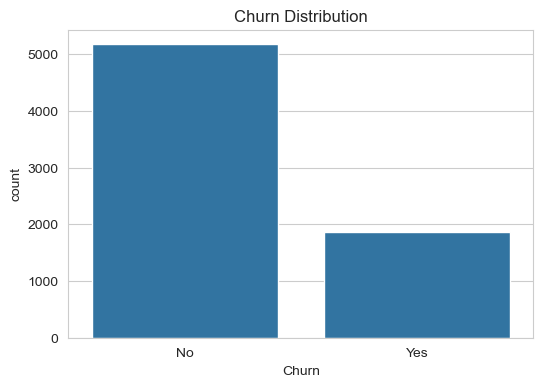

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

**Insight:**  
A significant number of customers have churned, which highlights the importance of analyzing customer retention factors.

### Churn by Contract Type

This analysis helps us understand whether contract type affects churn behavior.

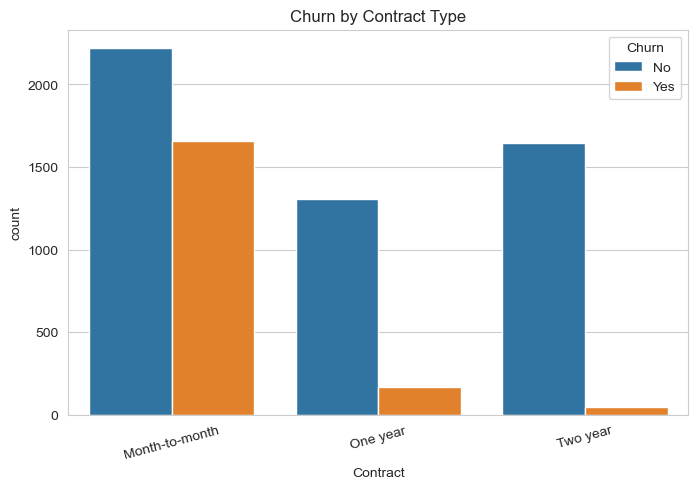

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

**Insight:**  
Customers with month-to-month contracts show a much higher churn rate compared to customers with one-year or two-year contracts.

### Tenure vs Churn

This analysis helps us understand whether the number of months a customer has stayed with the company influences churn.

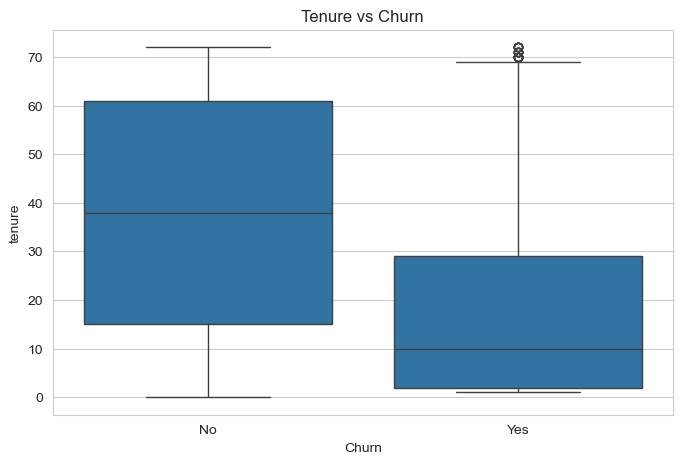

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

**Insight:**  
Customers with lower tenure are more likely to churn, while long-term customers are more likely to stay with the company.

### Monthly Charges vs Churn

This analysis examines whether customers with higher monthly charges are more likely to leave.

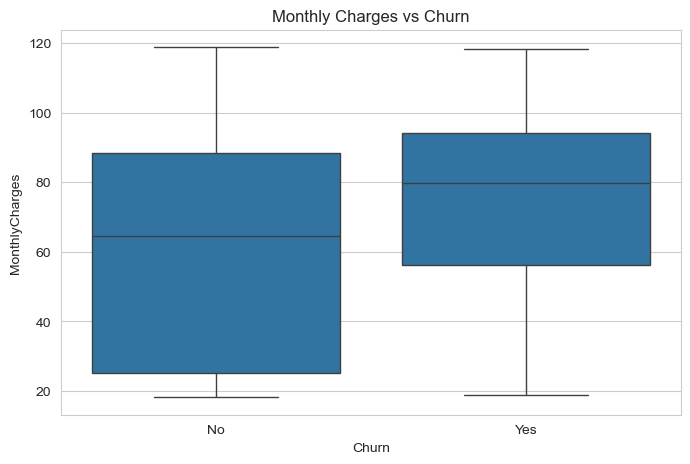

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:**  
Customers with higher monthly charges tend to churn more, which suggests that pricing could be an important factor influencing customer decisions.

### Churn by Internet Service

This analysis shows the relationship between internet service type and customer churn.

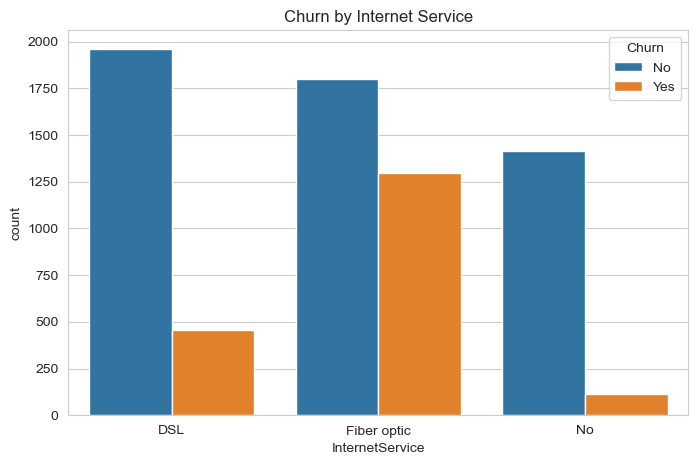

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service")
plt.show()

**Insight:**  
Churn behavior varies across internet service types, indicating that the quality or suitability of certain services may affect customer retention.

### Churn by Payment Method

This analysis helps identify whether payment method has any influence on churn behavior.

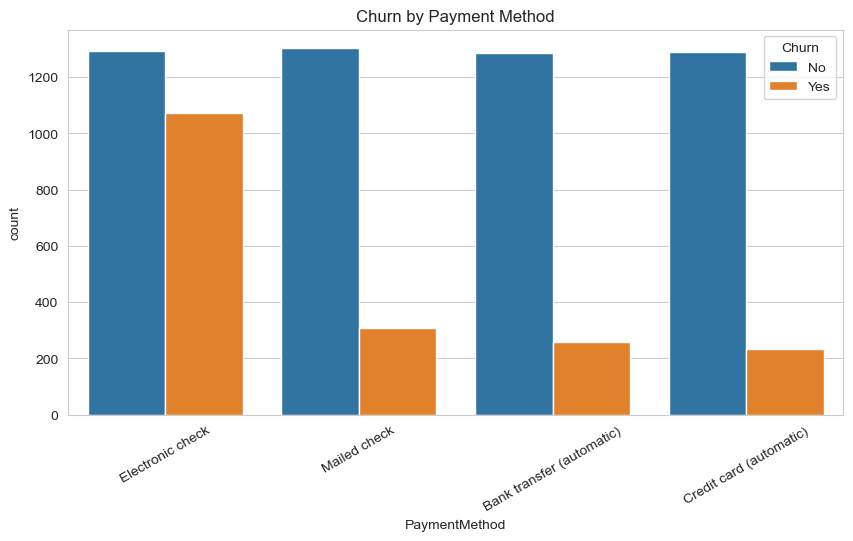

In [20]:
plt.figure(figsize=(10, 5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=30)
plt.show()

**Insight:**  
Certain payment methods show a higher churn rate, which may indicate convenience, trust, or billing experience issues.

### Churn by Senior Citizen

This analysis checks whether senior citizens churn more frequently than non-senior customers.

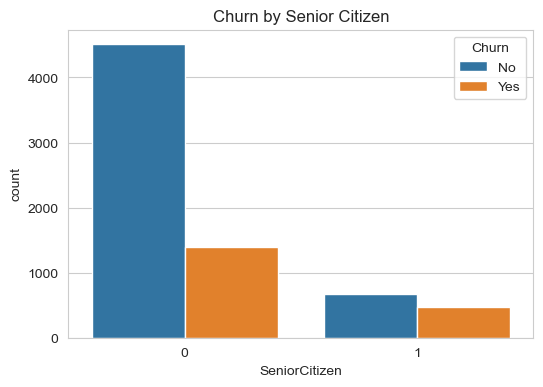

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Churn by Senior Citizen")
plt.show()

**Insight:**  
Senior citizens may show different churn behavior compared to non-senior customers, which can help businesses build targeted retention strategies.

## 5. Data Preprocessing

Before building the model, categorical columns must be converted into numerical form so that machine learning algorithms can process them.

## 5. Data Preprocessing

Before building the model, categorical columns must be converted into numerical form so that machine learning algorithms can process them.

In [25]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [26]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


### Correlation Heatmap

The heatmap helps identify the relationships between different variables and their impact on churn.

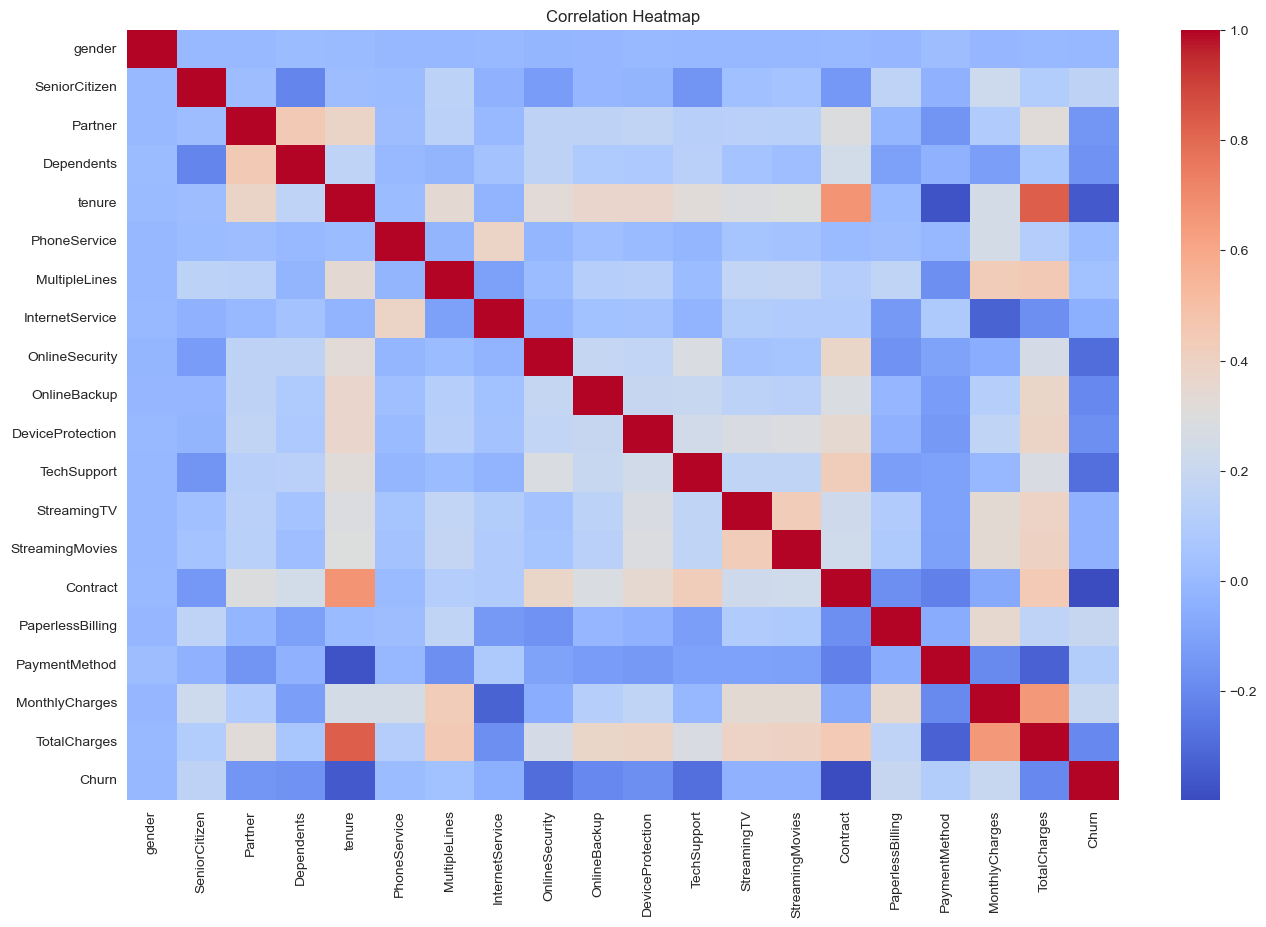

In [27]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insight:**  
The heatmap shows how different variables are related to churn. Features such as tenure, monthly charges, and contract type are important in understanding churn behavior.

## 6. Churn Prediction Model

A Logistic Regression model is used for churn prediction because churn is a binary classification problem.

In [29]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred = model.predict(X_test)

## 7. Model Evaluation

The model is evaluated using accuracy, confusion matrix, and classification report.

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8147622427253371


In [34]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[934 102]
 [159 214]]


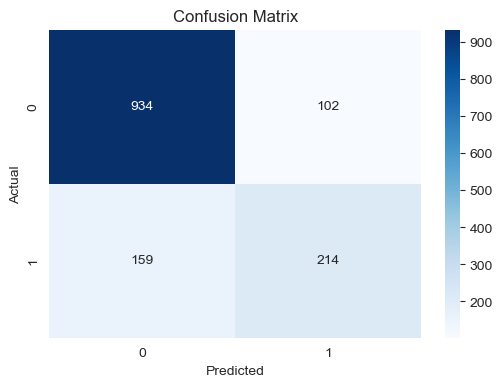

In [35]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



**Insight:**  
The Logistic Regression model provides a basic understanding of customer churn prediction. It helps identify at-risk customers and can support retention-focused decision-making.

## 8. Conclusion

- Customers with month-to-month contracts are more likely to churn.
- Customers with shorter tenure show a higher risk of leaving.
- Higher monthly charges are associated with increased churn.
- Contract type, internet service, and tenure are strong indicators of churn behavior.

### Business Recommendations:
- Offer discounts or loyalty benefits to new customers.
- Encourage customers to move from month-to-month plans to long-term contracts.
- Improve service quality for high-risk customer groups.
- Use churn prediction to identify and retain at-risk customers before they leave.

In [37]:
print("Project Completed Successfully")
print("Customer Churn Analysis and Prediction is ready.")

Project Completed Successfully
Customer Churn Analysis and Prediction is ready.
